<a href="https://colab.research.google.com/github/mahathimallela/OMIS-3020-Final-Group-Project-Heart-Disease/blob/main/OMIS_3020_Final_Project_ML_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

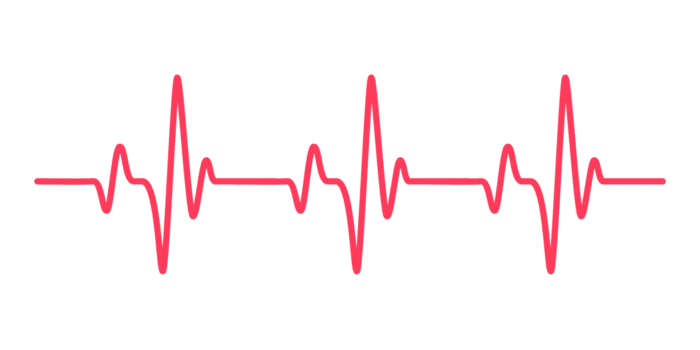

# OMIS 3020 Final Project

## **Machine Learning Modeling**

Data Loading and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Data Setup for ML**

In [2]:
# Load data
df = pd.read_csv("synthetic_heart_disease_risk_dataset-2.csv")
df.columns = [
    "Age", "Gender", "Resting_BP", "Cholesterol", "Fasting_Blood_Sugar",
    "Max_Heart_Rate", "ECG_Result", "Smoking_Status", "Alcohol_Consumption",
    "Physical_Activity_Level", "Diet_Quality_Score", "Sleep_Hours", "BMI",
    "Diabetes", "Hypertension", "Family_History", "Risk_Score",
    "Risk_Level", "Heart_Disease"
]


In [3]:
# Identifying numeric columns
numeric_cols = [
    "Age", "Resting_BP", "Cholesterol", "Fasting_Blood_Sugar", "Max_Heart_Rate",
    "Alcohol_Consumption", "Diet_Quality_Score", "Sleep_Hours", "BMI",
    "Diabetes", "Hypertension", "Family_History"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Splitting the data into features and the target variable
target = "Heart_Disease"
X = df.drop(columns=[target, "Risk_Score", "Risk_Level"])
y = df[target]

In [4]:
# Categorical features
cat_features = ["Gender", "ECG_Result", "Smoking_Status", "Physical_Activity_Level"]

# Numerical features
num_features = [
    "Age", "Resting_BP", "Cholesterol", "Fasting_Blood_Sugar", "Max_Heart_Rate",
    "Alcohol_Consumption", "Diet_Quality_Score", "Sleep_Hours", "BMI",
    "Diabetes", "Hypertension", "Family_History"
]


## **2. Model Development and Evaluation**

In [5]:
# Import statements to set up data preprocessing
# Using scikit-learn and pipeline to tie multiple data processing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipeline is for numerical features
# to get mean of 0 and standard deviation of 1, used StandardScaler
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# In case of missing categorical values, used SimpleImputer
# For the modeling later in the project, need to convert categorical values into a mumerical format. So, used onehotencoder
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

The data preprocessing pipeline is built on scikit-learn and it allows us to prepare raw data for machine learning. For analyzing the dataset and predicting for heart disease, we would need all features to work efficiently. This allow us to build a more accurate and reliable model.

## **3. Visualize Clusters**

The following uses PCA (Principal Component Analysis) where we reduced the heart disease dataset into 2 components. By doing so we wanted to visualize the cluster before any modeling. The 2D scatter plot to visualize clusters was found by K-means.

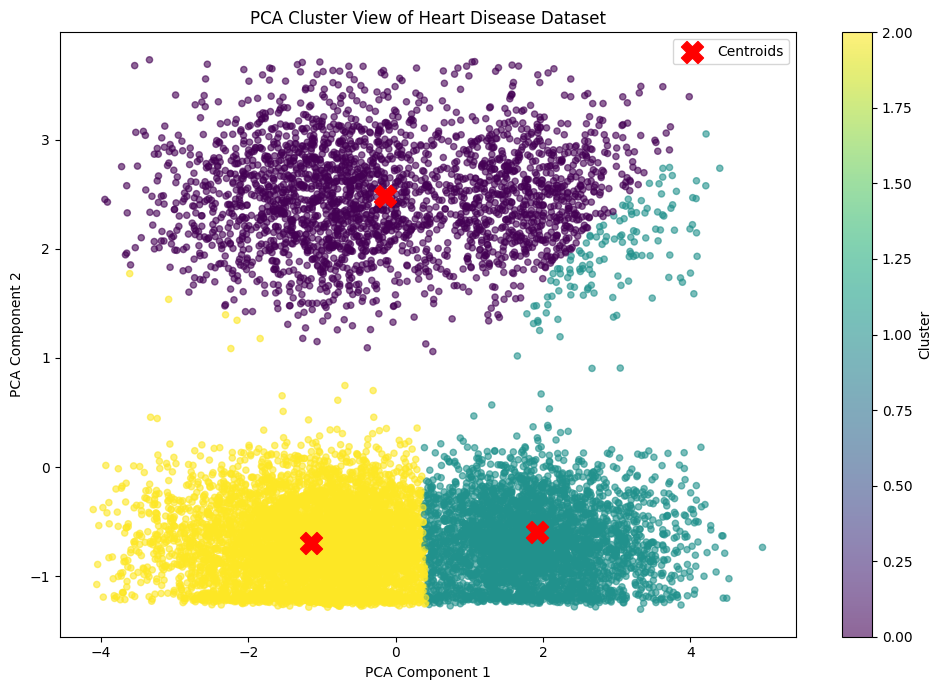

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Using PCA to create clusters for visualize of the different risk groups

X_processed = preprocessor.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.6, s=20)
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=250, marker="X", label="Centroids")
plt.title("PCA Cluster View of Heart Disease Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("cluster_visualization.png", dpi=300)
plt.show()

The above cluster visualization has 3 clusters to represent the low risk, medium risk, and high risk group.

## **4. Train & Test Model**

We are splitting the data into training and testing sets. 20% of the data will be used for the test set, and the remaining 80% will be used for training. We opted for random_state = 42 to get same split each time we run the code. Stratify was used to ensure the proportion of cases in both the traning and testing sets are roughly the same. We do not want a skewed representation of the model or any bias to occur.

In [7]:
from sklearn.model_selection import train_test_split

# Train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **5. Logistic Regression, KNN Classifier, and Random Forest Classifier**

The following code first sets up the dictionary of machine learning models that will be trained and evaluated.

We wanted to train 3 models:

1.   Logistic Regression:
This is a linear model to help us understand the relationship between features and the probability of a binary outcome. In our case, whether the patient from the synthetic data will likely have or not have heart disease. So we see features like Age, Cholesterol, Smoking Status for example that will contribute either positively or negatively to the risk of heart disease.


2.   KNN
For our project, KNN helps with being a comparison point. It helps determine if a simple, distance-based classification approach can effectively group individuals with similar characteristics and predict their heart disease status.

3. Random Forest Classfier
This model is also ideal for predicting heart disease and identifying the most important features. Random Forest provides a ranking of feature importance, and will help us in showing which factors are most influential



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Pipeline is for data preprocessing
# Creating models dictionary
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ]),
    "KNN": Pipeline([
        ("prep", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])
}

# Initialized empty list results. Later parts of code will store the accuracy and ROC-AUC of each model)
results = []

ROC Curve is where the x-axis represents the false positive rate and the y axis represents the true positive rate (ranging from 0 to 1). True Positive Rate (TPR) is called as sensitivity or recall and it is the proportion of actual positive cases of heart disease. The False Positive Rate is the proportion of actual negative cases of people without heart disease that were incorrectly identified by the model.

AUC is area under the curve and an auc of 1.0 = perfect model. AUC = 0.5 means model did not perfom better than random guessing. AUC < 0.5 = model is performing worse than random and is making wrong predictions.

So for our the insurance company for our project, a high ROC-AUC would tell us that the model has a strong ability to accurately identify individuals at risk of heart disease, which in turn implies that there are more accurate risk assessments for life policies.

In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

#accuracy_score, roc_auc_score, and confusion_matrix to quantify models' performances
# model.fit is the training step
# predict method is used to get the predicted class labels for heart disease on the unseen test features
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print("\n", name)
    print("Accuracy:", round(acc, 4))
    print("ROC-AUC:", round(auc, 4))
    print("Confusion Matrix:\n", cm)

    results.append([name, acc, auc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
print("\nModel Comparison:")
print(results_df.sort_values("ROC-AUC", ascending=False))


 Logistic Regression
Accuracy: 0.9908
ROC-AUC: 0.9999
Confusion Matrix:
 [[2354   22]
 [   0   24]]

 KNN
Accuracy: 0.9912
ROC-AUC: 0.9313
Confusion Matrix:
 [[2376    0]
 [  21    3]]

 Random Forest
Accuracy: 0.9921
ROC-AUC: 0.9975
Confusion Matrix:
 [[2376    0]
 [  19    5]]

Model Comparison:
                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.990833  0.999877
2        Random Forest  0.992083  0.997501
1                  KNN  0.991250  0.931327


Based on the results, **Logistic Regression** is the top performer with an ROC-AUC of 0.9999 and accuracy of 0.9908. The **Random Forest** also performed with a high ROC-AUC of 0.9975 and accuracy of 0.9921. **KNN** had a lower ROC-AUC compared to the other two at a value of 0.9313. It is less effective compared to the other two models.

## **6. Logistic Regression Coefficents**

The following code tell us how each feature impacts the likelihood of heart disease.

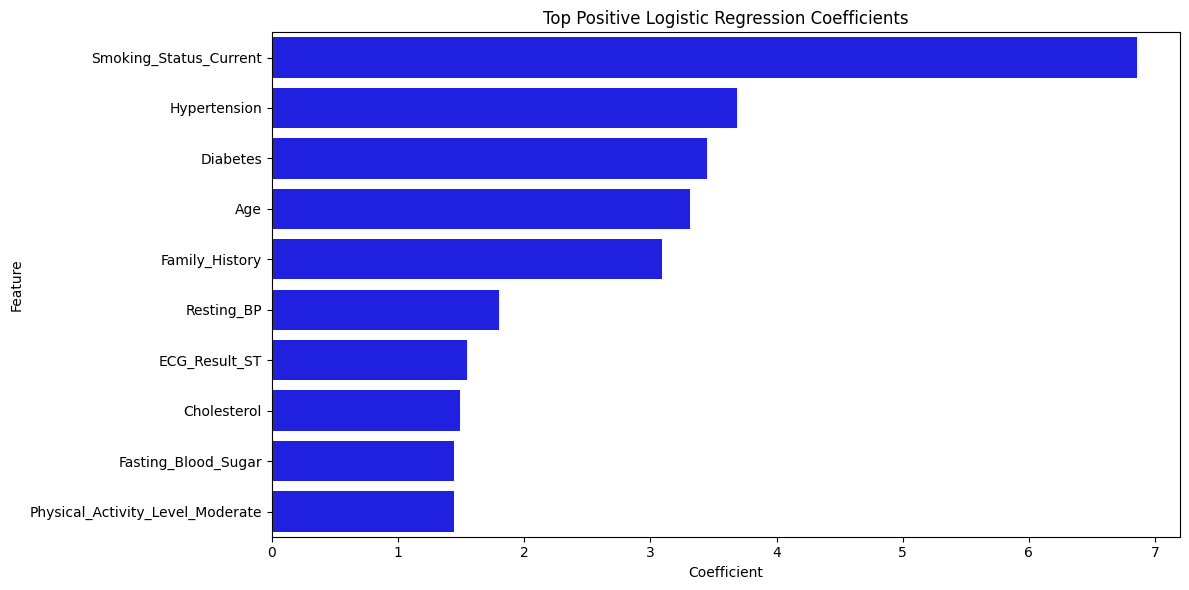

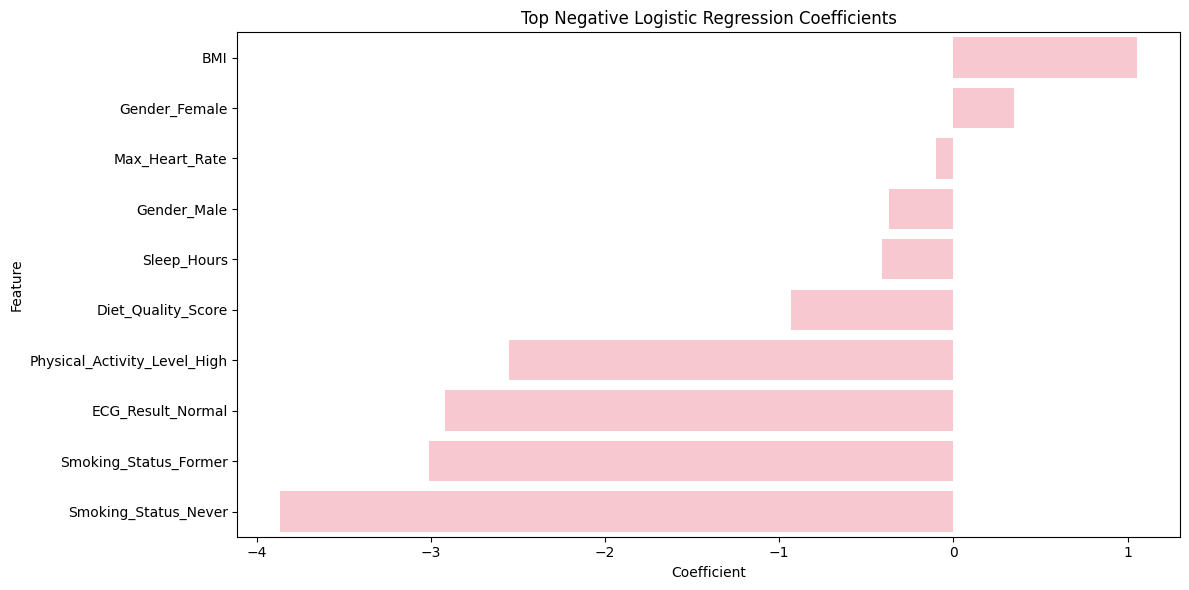

In [10]:
# log_model to retrieve the log regression from above
# onehotencoder will help with matching coefficients to the features
log_model = models["Logistic Regression"].named_steps["model"]
feature_names = num_features + list(
    models["Logistic Regression"].named_steps["prep"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(cat_features)
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

# top positive and top negative features towards likelihood of heart disease
top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)

# to display bar plots to see comparison and which features are stronger over others
plt.figure(figsize=(12, 6))
sns.barplot(data=top_pos, x="Coefficient", y="Feature", color="blue")
plt.title("Top Positive Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig("logistic_positive_coefficients.png", dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_neg, x="Coefficient", y="Feature", color="pink")
plt.title("Top Negative Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig("logistic_negative_coefficients.png", dpi=300)
plt.show()

From the bar plots for logistic regression, these are our interpretations:

Positive Coefficients:
Smoking_Status_Current has the highest coefficient of 6.85. So a constant and current smoker will drastically increase chances of heart disease. Though this is synthetic data, from the dataset it can be interpreted that the dummy patients and patients in a hypothetical setting are more likely to develop heart disease if they are a current smoker as opposed to ones that never smoked or stopped smoking.

Negative Coefficients:
The Negative Coefficients plot does the same to show which features would indicate a lower chance of heart disease.



## **7. Random Forest Interpretation**

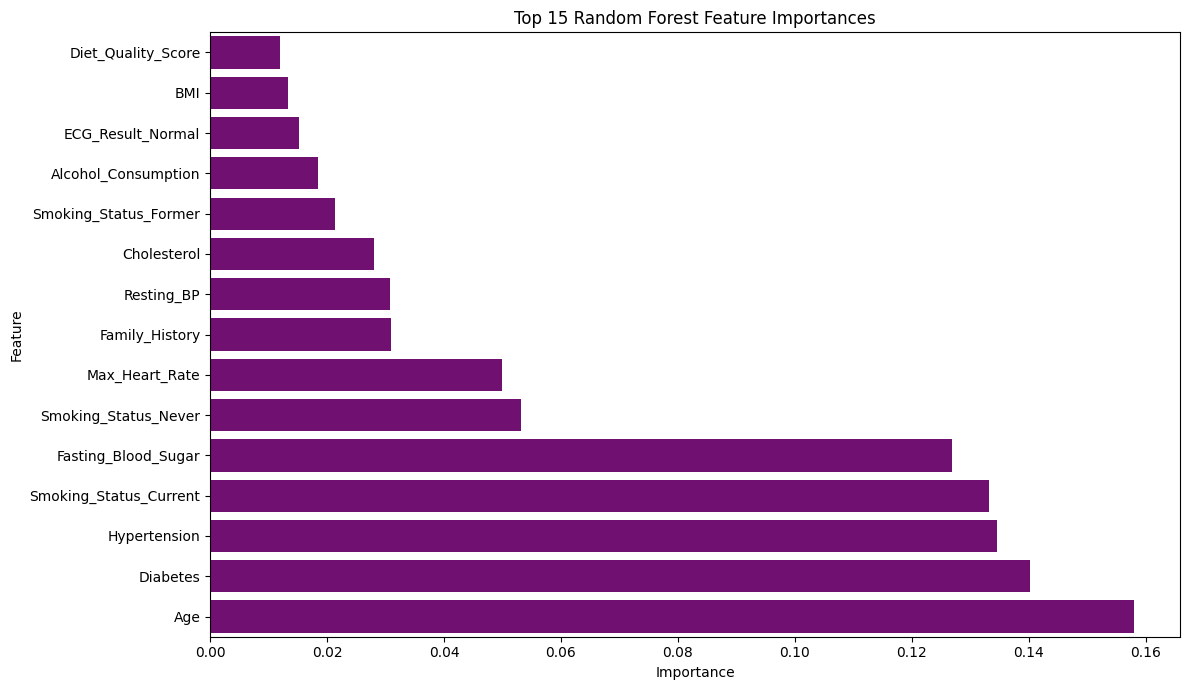

In [11]:
# rf_model accessed the Random Forest pipeline from models dictionary
rf_model = models["Random Forest"].named_steps["model"]
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=importance_df.sort_values("Importance"), x="Importance", y="Feature", color="purple")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("random_forest_importance.png", dpi=300)
plt.show()


The Random Forest feature plot tells us which features were most influential in the model's decision making process for predicting heart disease. From the output, Age has an importance of 0.1580, Diabetes has an importance of 0.1402, and then Hypertension, Smoking_Status_Current, and Fasting_Blood_Sugar follow. This is important information for our project and an insurance standpoint as well. It assesses which data to consider when determining if an individual should receive a life policy and if their medical status hinders them.

## **8. Target vs. Key Variables**

The following box plots are to once again help visualize the relationship between several key numerical variables and Heart Disease as target variable. For example, the box plot for Age likely shows that individuals with heart disease (=1) tend to have a higher median age and a wider distribution towards older ages compared to those without heart disease. So, age is a signficant risk factor for heart disease.

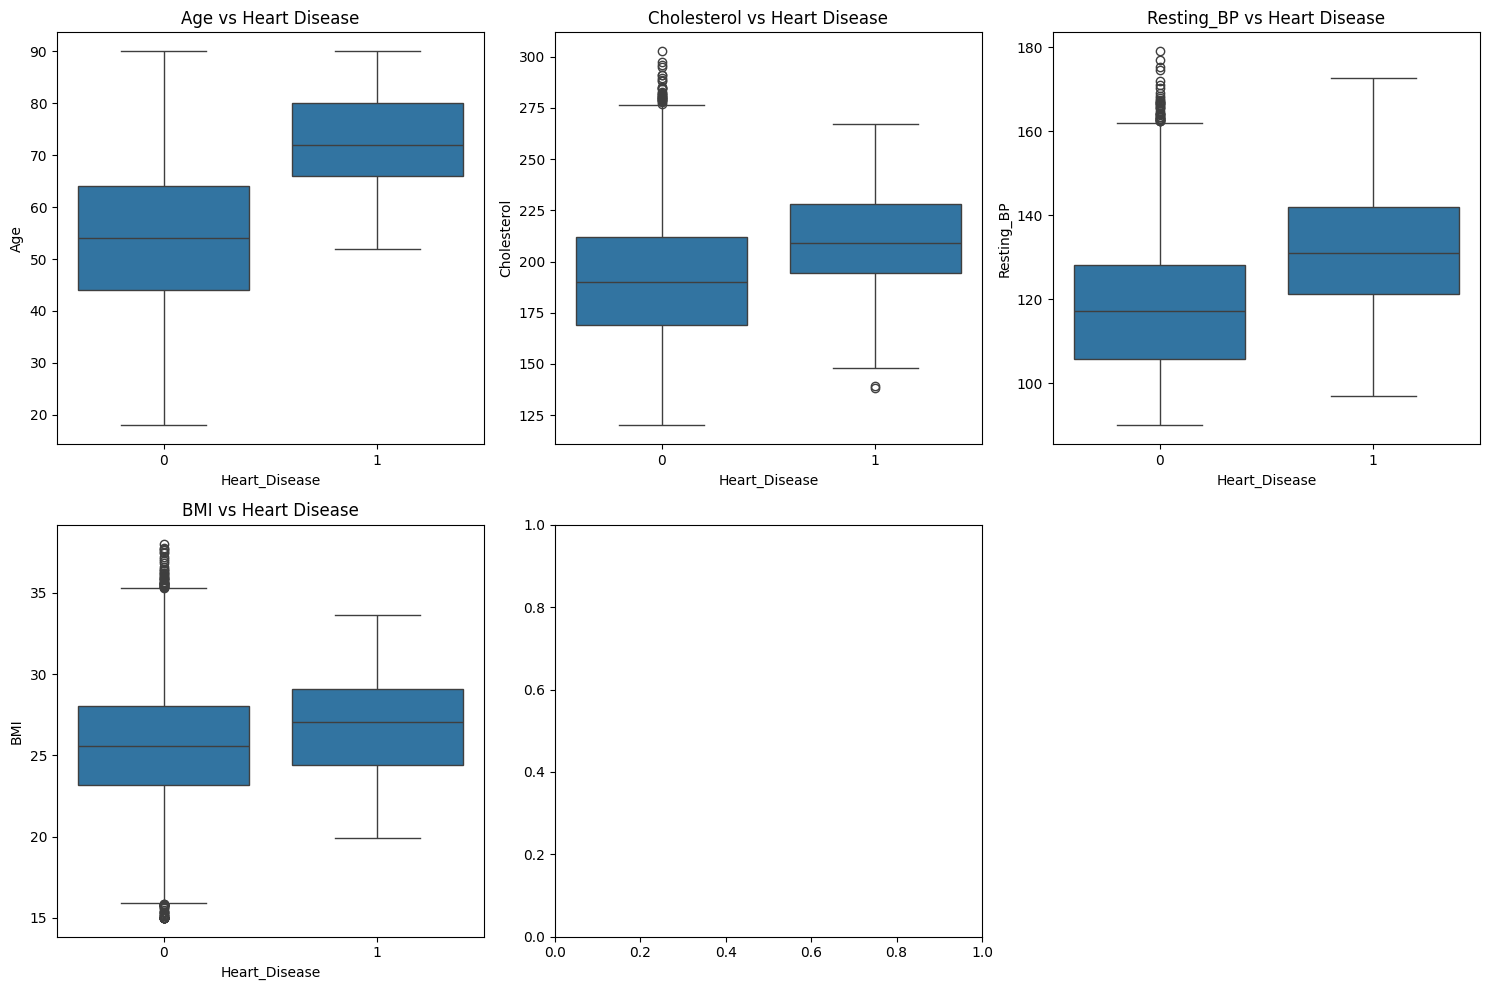

In [12]:
# summary of relationships of variables and target through box plots
key_vars = ["Age", "Cholesterol", "Resting_BP", "BMI"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(key_vars):
    sns.boxplot(data=df, x=target, y=var, ax=axes[i])
    axes[i].set_title(f"{var} vs Heart Disease")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("key_variable_boxes.png", dpi=300)
plt.show()

## **9. Model Performance Summary**

This is the Model Performance Summary. we can see that Logistic Regression achieved the highest ROC-AUC of 0.9999, followed closely by Random Forest at 0.9975. KNN had a significantly lower ROC-AUC of 0.9313. Logistic Regression is identified as the best performer.

In [13]:
print("Model Performance Summary")
print(results_df.sort_values("ROC-AUC", ascending=False))

# To identify which model performs better
max_roc_auc = results_df["ROC-AUC"].max()
best_models = results_df[results_df["ROC-AUC"] == max_roc_auc]["Model"].tolist()

print(f"\nBased on ROC-AUC, the best performing model is: {', '.join(best_models)}")
print("This models achieved effective and close to perfect prediction performance on this dataset.\n")

print("Key Indicators of Heart Disease:")
print("From Logistic Regression Coefficients (Top 5 Positive)")
print(top_pos.head(5).to_string(index=False))

print("From Random Forest Feature Importances (Top 5)")
print(importance_df.head(5).to_string(index=False))


Model Performance Summary
                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.990833  0.999877
2        Random Forest  0.992083  0.997501
1                  KNN  0.991250  0.931327

Based on ROC-AUC, the best performing model is: Logistic Regression
This models achieved effective and close to perfect prediction performance on this dataset.

Key Indicators of Heart Disease:
From Logistic Regression Coefficients (Top 5 Positive)
               Feature  Coefficient
Smoking_Status_Current     6.854515
          Hypertension     3.683499
              Diabetes     3.449118
                   Age     3.314542
        Family_History     3.091194
From Random Forest Feature Importances (Top 5)
               Feature  Importance
                   Age    0.157992
              Diabetes    0.140225
          Hypertension    0.134597
Smoking_Status_Current    0.133263
   Fasting_Blood_Sugar    0.126925


Consistently Top Risk Factors:
1. Smoking Status: Identified as the strongest positive indicator by Logistic Regression and a highly important feature by Random Forest. This is a critical red flag for insurers.

2. Age: Consistently ranked as a top predictor across both models. As individuals age, their risk naturally increases, a fundamental aspect of life insurance risk assessment.

3. Diabetes: A major health condition that significantly elevates heart disease risk, strongly highlighted by both models.

4. Hypertension (High Blood Pressure): Condition with an impact on heart health, prominently featured as a key risk indicator.

5. Family History: Logistic Regression pointed to this as a strong positive coefficient.

6. Fasting Blood Sugar: Random Forest identified this as a key feature, suggesting that even if not a full diabetes diagnosis, elevated blood sugar levels are an important risk factor.


In summary, the output clearly states that Logistic Regression is the top model based on ROC-AUC, and both top models consistently identify age, diabetes, hypertension, smoking status, and family history as the most significant indicators for predicting heart disease.  The Logistic Regression model stands out for its superior performance and interpretability, offering clear, actionable insights into the specific factors that most significantly drive heart disease risk

## **10. Dummy Patient Input Scenario for Insurance Life Policy**

The following code is an interactive way for insurance companies to flag which patients would be red flags and should be reevaluated with accruate medical records to determine if they qualify for the policy.

Eventhough the dataset is based on synthetic data, the data is validated with the patient information and understanding of medical history and which features in this model are strong indicators of heart diease. Therefore, we created an input simulation where either patient's input their medical data or insurance companies input data to make thresholds and benchmarks.

The prediction from this simulation should be remembered that it is based on synthetic data, but at the same time can be a precursor or warning signal for insurance companies when screening potential clients.

In [20]:
def patient_data_for_insurance(feature_columns):

    patient_data = {}
    print("\nPlease enter the following patient details:")
    for col in feature_columns:
        while True:
            try:
                value = input(f"Enter {col}: ")

                if col in num_features or col in ['Fasting_Blood_Sugar', 'Diabetes', 'Hypertension', 'Family_History', 'Alcohol_Consumption']:
                    patient_data[col] = float(value)
                elif col == 'Gender':

                    if value.lower() == 'male':
                        patient_data[col] = 'Male'
                        break
                    elif value.lower() == 'female':
                        patient_data[col] = 'Female'
                        break
                    else:
                        print("Invalid gender. Please enter 'Male' or 'Female'.")
                        continue
                elif col in ['ECG_Result', 'Smoking_Status', 'Physical_Activity_Level', 'Risk_Level']:
                    patient_data[col] = str(value)
                else:
                    patient_data[col] = str(value)
                break
            except ValueError:
                print(f"Invalid input for {col}. Please enter a numeric value.")
            except Exception as e:
                print(f"An unexpected error occurred: {e}")

    return patient_data

In [21]:
print("Life Policy Assessment")
if 'models' not in globals() or 'selected_model' not in locals():
    print("Warning: 'models' dictionary or 'selected_model' not found. Re-initializing Logistic Regression model.")
    selected_model = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ])
    # Fit the model
    try:
        selected_model.fit(X_train, y_train)
    except NameError:
        print("Error: X_train or y_train not defined. Please run all preceding cells.")
        exit()

Life Policy Assessment


In [25]:
def assess_patient_for_life_policy(patient_data, model, preprocessor, threshold=0.5):

    patient_df = pd.DataFrame([patient_data])


    for col in X.columns:
        if col not in patient_df.columns:

            if col in num_features:
                patient_df[col] = np.nan
            elif col in cat_features:
                patient_df[col] = 'Unknown'
            else:
                patient_df[col] = np.nan


    patient_df = patient_df[X.columns]
    prob_heart_disease = model.predict_proba(patient_df)[:, 1][0]

    recommendation = ""
    if prob_heart_disease >= threshold:
        recommendation = "Decline Policy (High Risk)"
    else:
        recommendation = "Approve Policy (Low Risk)"

    return {
        "Risk Probability": f"{prob_heart_disease:.4f}",
        "Policy Recommendation": recommendation
    }


if 'X' in globals():
    interactive_patient_data = patient_data_for_insurance(X.columns)

    interactive_assessment = assess_patient_for_life_policy(
        interactive_patient_data, selected_model, preprocessor, threshold=0.5
    )

    print("Interactive Patient Assessment Result")
    for key, value in interactive_assessment.items():
        print(f"  {key}: {value}")


    print("Feature Insights for Interactive Patient")
    try:
        if 'top_pos' in globals() and 'importance_df' in globals():
            # Combine top features from Logistic Regression and Random Forest
            top_lr_features = top_pos['Feature'].tolist()
            top_rf_features = importance_df['Feature'].tolist()


            significant_features_info = {}

            for f_list, source in [(top_lr_features, "Logistic Regression"), (top_rf_features, "Random Forest")]:
                for f in f_list:
                    base_feature = f
                    if f.startswith('Risk_Level_'):
                        base_feature = 'Risk_Level'
                    elif f.startswith('Smoking_Status_'):
                        base_feature = 'Smoking_Status'


                    if base_feature not in significant_features_info:
                        significant_features_info[base_feature] = {"sources": [source]}
                    else:
                        if source not in significant_features_info[base_feature]["sources"]:
                            significant_features_info[base_feature]["sources"].append(source)

            # Sort features
            sorted_significant_features = sorted(significant_features_info.keys())

            print("\nBased on the models' identified top positive/important features:")
            for feature in sorted_significant_features:
                if feature in interactive_patient_data:
                    patient_value = interactive_patient_data[feature]
                    sources = significant_features_info[feature]["sources"]
                    source_str = " and ".join(sources)

                    print(f"{feature} identified by {source_str}: Patient value is {patient_value}.")


                    if feature == 'Risk_Level':

                        if isinstance(patient_value, str) and patient_value.lower() == 'high':
                            print("\nInsight: This patient's Risk Level is High, which is a significant indicator for heart disease.")
                        else:
                            print(f"\nInsight: Patient's Risk Level is {patient_value}, which is not a High risk indicator.")

                    elif feature == 'Risk_Score':

                        if patient_value > 70:
                            print(f"\nInsight: This patient's Risk Score {patient_value} is relatively high, strongly associated with heart disease.")
                        else:
                            print(f"\nInsight: Patient's Risk Score {patient_value} is not unusually high.")

                    elif feature == 'Smoking_Status':
                        if isinstance(patient_value, str) and patient_value.lower() == 'current':
                            print("\nInsight: This patient is a Current smoker, a major risk factor for heart disease.")
                        else:
                            print(f"\nInsight: Patient's Smoking Status is {patient_value}, which is not a Current smoker high-risk indicator.")

                    elif feature == 'Diabetes':
                        if patient_value == 1:
                            print("\nInsight: This patient has Diabetes (indicated by 1), a significant contributor to heart disease risk.")
                        else:
                            print("\nInsight: This patient does not have Diabetes (indicated by 0).")

                    elif feature == 'Hypertension':
                        if patient_value == 1:
                            print("\nInsight: This patient has Hypertension (indicated by 1), a key risk factor for heart disease.")
                        else:
                            print("\nInsight: This patient does not have Hypertension (indicated by 0).")

                    elif feature == 'Age':

                        if patient_value > 60:
                            print(f"\nInsight: This patient's Age {patient_value} is relatively high, which is a known risk factor for heart disease.")
                        else:
                            print(f"\nInsight: Patient's Age {patient_value} is not in the higher risk bracket.")


                    else:
                        print("\nInsight: Specific insight for this feature not yet implemented.")

                else:
                    print(f"{feature}: Not provided in patient data. Cannot provide specific insight.")
            print("\nThese insights highlight how the patient's individual characteristics align with known heart disease risk factors identified by the models.")

        else:
            print("\nReminder this is synthetic dataset; additional tests should be run by insurance companies to process the policy")

    except NameError as e:
        print(f"NameError")
else:
    print("DataFrame not found")


Please enter the following patient details:
Enter Age: 56
Enter Gender: Male
Enter Resting_BP: 180
Enter Cholesterol: 160
Enter Fasting_Blood_Sugar: 89
Enter Max_Heart_Rate: 180
Enter ECG_Result: 89
Enter Smoking_Status: Current
Enter Alcohol_Consumption: 9
Enter Physical_Activity_Level: Low
Enter Diet_Quality_Score: 2
Enter Sleep_Hours: 2
Enter BMI: 23
Enter Diabetes: 1
Enter Hypertension: 1
Enter Family_History: 0
Interactive Patient Assessment Result
  Risk Probability: 0.9984
  Policy Recommendation: Decline Policy (High Risk)
Feature Insights for Interactive Patient

Based on the models' identified top positive/important features:
Age identified by Logistic Regression and Random Forest: Patient value is 56.0.

Insight: Patient's Age 56.0 is not in the higher risk bracket.
Alcohol_Consumption identified by Random Forest: Patient value is 9.0.

Insight: Specific insight for this feature not yet implemented.
BMI identified by Random Forest: Patient value is 23.0.

Insight: Specific 